
### **Olist E-Commerce: Customer Lifetime Value (CLTV) Prediction Framework**

**Business Scenario**
As part of the upcoming quarterly budget allocation, Olist's Marketing Department requires a predictive framework to estimate the future value of the existing customer base. This analysis transitions customer evaluation from a historical, single-transaction perspective to a forward-looking valuation model.

**Objectives**

1. **Data Engineering:** Aggregate relational tables to form a unified transactional dataset and perform robust data cleaning.
2. **Exploratory Data Analysis:** Analyze customer behavior metrics (Recency, Frequency, Monetary Value).
3. **Predictive Modeling:** Estimate CLTV utilizing both probabilistic "Buy 'Til You Die" (BTYD) frameworks (BG/NBD and Gamma-Gamma) and Machine Learning regression models.
4. **Strategic Recommendations:** Synthesize model outputs to identify high-value segments and prioritize candidates for targeted "win-back" campaigns.

---

### **2. Library Imports & Data Aggregation**

To calculate CLTV, we need a customer's unique identity, the timestamps of their orders, and the monetary value/quantity of those orders. This requires joining the `customers`, `orders`, and `order_items` tables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from pathlib import Path

data_dir = Path('Brazilian_E-Commerce_Dataset')

customers = pd.read_csv(data_dir / 'olist_customers_dataset.csv')
orders = pd.read_csv(data_dir / 'olist_orders_dataset.csv')
items = pd.read_csv(data_dir / 'olist_order_items_dataset.csv')
payments = pd.read_csv(data_dir / 'olist_order_payments_dataset.csv')

df = pd.merge(orders, customers, on='customer_id', how='inner')
df = pd.merge(df, items, on='order_id', how='inner')
df = pd.merge(df, payments, on='order_id', how='inner')

df.info()
df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   customer_unique_id             117601 non-null  object 
 9   customer_zip_code_prefix       117601 non-null  int64  
 10  customer_city                  117601 non-null  object 
 11  customer_state                 117601 non-null  object 
 12  order_item_id                 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12


### Estimating Customer Lifetime Value (CLTV)

Our primary objective is to estimate Customer Lifetime Value (CLTV), the conceptual intersection of corporate finance and marketing strategy. Historically, organizations focused primarily on acquisition costs—asking, "How much capital is required to acquire a new customer?" The CLTV paradigm shifts this focus toward long-term profitability, evaluating the total economic value a customer will generate throughout their entire relationship with the company.

To accurately predict this future value, we rely on foundational behavioral signals. The canonical feature triad used for this prediction is **RFM** (Recency, Frequency, and Monetary value). These metrics are computationally straightforward yet remarkably predictive:

* **Recency (R) — *How recently did the customer transact?***
Recency serves as the strongest indicator of future activity. A dormant customer is highly likely to churn, making the time since their last purchase a critical signal of their active status.
* **Frequency (F) — *How many times has the customer purchased?***
Frequency measures the depth of customer engagement. It signals established loyalty and habit formation that extends beyond a single transactional interaction.
* **Monetary Value (M) — *How much has the customer spent?***
Monetary value quantifies the customer's historical economic contribution, serving as the baseline anchor for predicting expected future spend.

### Data Audit & Quality: Establishing Ground Truth

Before we can accurately predict a customer's future value, we must ensure our historical data represents genuine, revenue-generating behavior. A predictive model is only as good as the signal it receives, so our first step is to interrogate the dataset and clean up any inconsistencies that violate our business logic.

We will apply a strict three-step auditing strategy:

**1. Removing Orphaned Transactions (Missing Customer IDs)**
* **The Context:** CLTV fundamentally relies on tracking an individual's purchasing journey over time. 
* **The Action:** If a transaction lacks a `customer_unique_id`, we cannot link it to a specific person or calculate their purchasing frequency. These rows must be dropped.

**2. Handling System Duplicates**
* **The Context:** Perfectly identical rows in transactional databases are almost always logging errors or accidental double-submissions at checkout, not simultaneous identical purchases.
* **The Action:** We will drop exact duplicates to prevent artificially inflating our Frequency (F) and Monetary (M) signals.

**3. Filtering Economic Anomalies**
* **The Context:** Items with a price of zero (or lower, if present) typically represent bad-debt adjustments, incorrectly applied discounts, or system errors. 
* **The Action:** Since our objective is to model expected *positive revenue*, we will filter the dataset to strictly include valid purchases where the `price` is greater than zero.

In [2]:
df = df.dropna(subset=['customer_unique_id'])
df = df.drop_duplicates()
df = df[df['price'] > 0]

### Categorical Inspection: Unique Values & Value Counts

We will check unique values in order to find **categorical anomalies**. 


In [3]:
status_counts = df['order_status'].value_counts(dropna=False)
print("Order Statuses:\n", status_counts)

print("\n" + "-"*30 + "\n")

payment_counts = df['payment_type'].value_counts(dropna=False)
print("Payment Types:\n", payment_counts)

Order Statuses:
 order_status
delivered      115035
shipped          1244
canceled          566
processing        375
invoiced          371
unavailable         7
approved            3
Name: count, dtype: int64

------------------------------

Payment Types:
 payment_type
credit_card    86769
boleto         22867
voucher         6274
debit_card      1691
Name: count, dtype: int64


### Categorical Data Audit: Validating Revenue Streams

After cleaning our numerical anomalies, we must ensure our categorical data logically supports a predictive financial model. Customer Lifetime Value (CLTV) relies strictly on realized revenue. Therefore, we must inspect the categorical status of our transactions. 

Specifically, we need to verify:
1. **Order Status:** We must identify and exclude incomplete transactions (e.g., `canceled`, `unavailable`, or `processing`). Only `delivered` orders represent actual, realized value.
2. **Payment Types:** We must check for system errors or placeholder values (such as `not_defined`) that could invalidate the financial tracking of the order.

Below, we inspect these distributions and filter the dataset to isolate genuine, completed purchases.

In [4]:
# 1. Inspect the categorical distributions
print("--- Order Status Distribution ---")
print(df['order_status'].value_counts(dropna=False))

print("\n--- Payment Type Distribution ---")
print(df['payment_type'].value_counts(dropna=False))

# 2. Apply strict business logic filters for CLTV

# Keep strictly fully realized (delivered) orders
df = df[df['order_status'] == 'delivered']

# Remove invalid payment placeholders (if any exist in the dataset)
df = df[df['payment_type'] != 'not_defined']

print(f"\nFinal cleaned dataset shape ready for RFM modeling: {df.shape}")

--- Order Status Distribution ---
order_status
delivered      115035
shipped          1244
canceled          566
processing        375
invoiced          371
unavailable         7
approved            3
Name: count, dtype: int64

--- Payment Type Distribution ---
payment_type
credit_card    86769
boleto         22867
voucher         6274
debit_card      1691
Name: count, dtype: int64

Final cleaned dataset shape ready for RFM modeling: (115035, 22)


### Methodological Justification: Defining the Revenue Baseline

When establishing the foundational dataset for Customer Lifetime Value (CLTV) modeling, a critical distinction must be made between a customer's *intent to buy* and *realized revenue*. To ensure the integrity of the predictive framework, we must define a strict boundary for valid transactions.

#### The Ideal Framework vs. Data Constraints
In an ideal financial modeling scenario, an order should only be recognized as realized revenue once the contract of sale is completely irrevocable. This implies two conditions:
1. The product has been successfully fulfilled and is in the possession of the customer.
2. The legal timeframe for returns, cancellations, or refund policies has entirely elapsed (often referred to as the transaction's *maturation period*). 

Transactions that fall within the active return window represent an outstanding financial liability, as they carry a risk of reversal that would artificially inflate our Recency, Frequency, and Monetary (RFM) signals.

#### Our Executive Approach
Because the dataset does not explicitly provide granular granular tracking of individual refund eligibility windows or post-delivery return logs, we must optimize for maximum certainty. 

Therefore, we apply the following business rules:
* **Exclusion of Canceled and Pending States:** Statuses such as `canceled`, `unavailable`, `processing`, and `shipped` are omitted. Including these would introduce structural noise, leading the BG/NBD and Gamma-Gamma models to overestimate customer engagement and future spend based on unfulfilled or failed transactions.
* **Strict Reliance on `delivered` Status:** By filtering the dataset to strictly contain `delivered` orders, we isolate the highest possible level of transactional certainty available to us. This ensures that our calibration baseline is anchored entirely on verified, completed transactions where the product has successfully reached the consumer.

In [5]:
status_counts = df['order_status'].value_counts(dropna=False)
print("Order Statuses:\n", status_counts)

print("\n" + "-"*30 + "\n")





Order Statuses:
 order_status
delivered    115035
Name: count, dtype: int64

------------------------------



### data transformation: credit card type and datetime



In [6]:
df['payment_type'] = df['payment_type'].replace({
    'credit_card': 'card',
    'debit_card': 'card'
})

payment_counts = df['payment_type'].value_counts(dropna=False)
print("Payment Types:\n", payment_counts)

Payment Types:
 payment_type
card       86550
boleto     22362
voucher     6123
Name: count, dtype: int64


In [7]:
#Cast the timestamp to a true datetime object

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Verify the fix
print("Data type after conversion:", df['order_purchase_timestamp'].dtype)

# 3. Find the timeline boundaries to plan our Holdout period
max_date = df['order_purchase_timestamp'].max()
min_date = df['order_purchase_timestamp'].min()

print(f"\nDataset Timeline:")
print(f"First purchase: {min_date}")
print(f"Last purchase: {max_date}")

Data type after conversion: datetime64[ns]

Dataset Timeline:
First purchase: 2016-10-03 09:44:50
Last purchase: 2018-08-29 15:00:37


### Data Transformation, Type Casting, & Outlier Detection

Now that our transactional data has been filtered logically, we must transition to structural data formatting and statistical quality control. This phase focuses on type casting and managing distribution outliers:

**1. Temporal Type Casting (Datetime Formatting)**
* **The Context:** Our raw dataset imports vital temporal features like `order_purchase_timestamp` as general text strings (`object` data type). 
* **The Action:** For probabilistic modeling (BG/NBD), time deltas are critical. We must explicitly cast our timestamp variables into true `datetime64[ns]` formats so pandas can perform chronological math (e.g., calculating customer tenure and recency).

**2. Statistical Outlier Management**
* **The Context:** E-commerce data frequently contains extreme outliers—either from legitimate high-volume wholesale buyers or data-entry anomalies. While models can handle standard variance, extreme values severely warp both the Gamma-Gamma monetary estimations and machine learning regression algorithms.
* **The Action:** We will evaluate the statistical boundaries of our core continuous variables (`price`, `freight_value`, and `payment_value`). To preserve the integrity of our predictive frameworks without destroying meaningful data, we will apply an upper-bound cap at the 99th percentile to clamp extreme, unrepresentative spikes.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115035 entries, 0 to 117600
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115035 non-null  object        
 1   customer_id                    115035 non-null  object        
 2   order_status                   115035 non-null  object        
 3   order_purchase_timestamp       115035 non-null  datetime64[ns]
 4   order_approved_at              115020 non-null  object        
 5   order_delivered_carrier_date   115033 non-null  object        
 6   order_delivered_customer_date  115027 non-null  object        
 7   order_estimated_delivery_date  115035 non-null  object        
 8   customer_unique_id             115035 non-null  object        
 9   customer_zip_code_prefix       115035 non-null  int64         
 10  customer_city                  115035 non-null  object        
 11  custo

### Data Transformation: Aggregating from Item-Level to Order-Level

The raw Olist dataset is structured at the *item-level*, meaning a single checkout containing multiple items generates multiple rows. However, our objective requires us to analyze customer behavior based on *order values and quantities*. 

To fulfill this requirement, we must perform an aggregation to compress the dataset into a true *order-level* architecture:
1. **Quantity:** We will calculate the total number of items in the cart by extracting the maximum `order_item_id` per `order_id`.
2. **Total Order Value:** We will sum the `price` of all items within the same `order_id` to calculate the true basket value.

Once aggregated, we can accurately identify and manage extreme outliers in basket sizes (quantities) and total values before moving into our RFM modeling.

In [9]:
import pandas as pd

# 1. Ensure the timestamp is mathematically actionable
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Aggregate the dataset to the true ORDER level
df = df.groupby('order_id').agg(
    # Create our new order-level metrics
    quantity=('order_item_id', 'max'),         
    total_order_price=('price', 'sum'),        
    
    # Retain the first instance of contextual/behavioral data per order
    customer_unique_id=('customer_unique_id', 'first'),
    order_purchase_timestamp=('order_purchase_timestamp', 'first'),
    payment_value=('payment_value', 'first'),
    freight_value=('freight_value', 'first'),
    payment_installments=('payment_installments', 'first'),
    customer_state=('customer_state', 'first')
).reset_index()



### Feature Selection: Dimensionality Reduction & Strategic Isolation

Our objective requires two distinct modeling approaches (Probabilistic BTYD and Machine Learning Regression), which have conflicting data appetites. To satisfy both without cluttering our memory or introducing noise, we will isolate a core subset of features from our raw dataset and discard the rest.

#### 1. The Core RFM Drivers (Kept for Both Tracks)
The BG/NBD and Gamma-Gamma models are mathematical purists. They require only the strict dimensions of a transaction. We keep:
* `customer_unique_id`: The true, persistent identifier of the individual (our "Who").
* `order_purchase_timestamp`: The exact anchor for calculating Recency and Tenure (our "When").
* `price` & `payment_value`: The realized economic value of the basket (our "How Much").

#### 2. The Behavioral Indicators (Kept for Machine Learning)
Unlike probabilistic models, regression algorithms (like XGBoost or Random Forest) thrive on contextual data. We retain specific columns because they are proven behavioral indicators of purchasing power and retention:
* `payment_type` & `payment_installments`: Reliance on credit, cash, or installments heavily influences future lifetime value.
* `freight_value`: Shipping costs act as a primary friction point for e-commerce retention.
* `customer_state`: Captures regional macroeconomic differences in purchasing power across Brazil.

#### 3. The Discarded Noise (Dropped)
To prevent overfitting, we aggressively drop columns that do not serve long-term behavioral prediction:
* **Temporary IDs:** `customer_id` is a temporary session token, not a persistent user ID. `order_id` is too granular.
* **Logistics Artifacts:** Timestamps like `order_delivered_carrier_date` track operational warehouse efficiency, not consumer desire.
* **High-Cardinality Identifiers:** `product_id`, `seller_id`, and `customer_zip_code_prefix` contain too many unique string values, which would fracture our machine learning models without adding proportional predictive value.

In [10]:
# Define the strategic columns mapped out in our feature selection
"""features_to_keep = [
    'customer_unique_id', 
    'order_purchase_timestamp', 
    'price', 
    'payment_value', 
    'freight_value', 
    'payment_type',
    'payment_installments',
    'customer_state'
]
"""
# 3. Drop the redundant 'order_id' and lock in our final feature list
features_to_keep = [
    'customer_unique_id', 'order_purchase_timestamp', 'total_order_price', 
    'quantity', 'payment_value', 'freight_value', 'payment_installments', 'customer_state'
]

# Create the finalized, streamlined dataframe 
# (Note: Using df_cleaned assuming that is where your filtered data lives. 
# If your notebook memory reset, change df_cleaned to df)
df = df[features_to_keep]

print(f"Original item-level rows: {len(df)}")
print(f"Final aggregated order-level rows: {len(df)}")
print("-" * 50)
df.info()

Original item-level rows: 96477
Final aggregated order-level rows: 96477
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96477 entries, 0 to 96476
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        96477 non-null  object        
 1   order_purchase_timestamp  96477 non-null  datetime64[ns]
 2   total_order_price         96477 non-null  float64       
 3   quantity                  96477 non-null  int64         
 4   payment_value             96477 non-null  float64       
 5   freight_value             96477 non-null  float64       
 6   payment_installments      96477 non-null  int64         
 7   customer_state            96477 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(2)
memory usage: 5.9+ MB


### Strategic Decision: Defining the Monetary Metric for CLTV

When establishing the *Monetary* (M) baseline for Customer Lifetime Value modeling, a critical methodological divergence emerges. The Olist dataset distinctly separates the net cost of the goods (`price`) from the logistics cost (`freight_value`) and the final charged amount (`payment_value`). 

Deciding which configuration truly represents "customer value" requires analyzing two opposing business philosophies:

#### 1. The Consumer Perspective (Share of Wallet & Willingness to Pay)
From a behavioral psychology standpoint, the consumer makes no distinction between the cost of the item and the cost of shipping: the total cash outflow from their bank account represents their actual economic friction and commitment to the purchase. 
* **The Rationale:** Utilizing the gross `payment_value` allows us to map the user's exact *Willingness to Pay* and overall *Share of Wallet*. Furthermore, if a customer utilizes financing (installments) or loyalty vouchers, `payment_value` captures the true transactional reality. If Marketing's objective is to identify high-spending VIPs and measure their propensity to allocate budget to our platform, this gross behavioral metric is the strongest indicator.

#### 2. The Financial Perspective (Net Revenue & Unit Economics)
Conversely, from a strict accounting and corporate treasury perspective, revenue generated from shipping (`freight_value`) is a *pass-through cost*—it does not remain with the company but is immediately transferred to logistics partners.
* **The Rationale:** If the primary goal of this predictive model is future budget allocation, we must rely exclusively on the net `price`. Calculating Lifetime Value by including shipping costs or ignoring voucher deficits artificially inflates the financial value of the customer base. This overestimation is dangerous: it can lead the Marketing team to overspend on Customer Acquisition Costs (skewing the LTV:CAC ratio) based on phantom profit margins.

**Executive Conclusion:** Both metrics offer valid signals, but they answer fundamentally different business questions (Behavioral Loyalty vs. Financial Profitability).

**Executive Conclusion:** Both metrics offer valid signals, but they answer fundamentally different business questions. Because the primary objective of this model is to support the Marketing Department's future **budget allocation**, we must prioritize strict financial profitability over gross behavioral metrics. Therefore, we will proceed using the net **`price`** as our Monetary (M) baseline. This ensures that our predictive Lifetime Value represents true net revenue, protecting the business from overestimating customer value based on pass-through logistics costs.

## Managing Outliers and Extreme Values

Before altering the data, we visually inspect the distribution of our newly aggregated continuous numeric features (`total_order_price`, `quantity`, `payment_value`, `freight_value`, `payment_installments`). By plotting both Histograms and Boxplots, we can confirm the presence of heavy right-tail outliers (e.g., massive B2B wholesale orders) that justify our statistical capping strategy.

While we could apply the standard 3x IQR rule for outlier detection, e-commerce data naturally contains highly skewed, valid transactions (such as large B2B wholesale orders). 

Therefore, rather than dropping these records, we will opt to cap our continuous variables at the 99th percentile. This approach mitigates the disruptive impact of extreme anomalies on our predictive models while preserving the integrity of our high-value customer data.





In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define our continuous numeric columns
numeric_cols = ['total_order_price', 'quantity', 'payment_value', 'freight_value', 'payment_installments']

# Set up the visual grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 20))
fig.suptitle('Pre-Treatment Distribution and Outlier Analysis (Order-Level)', fontsize=18, fontweight='bold', y=1.02)

for i, col in enumerate(numeric_cols):
    # Plot 1: Histogram
    sns.histplot(df_rfm_base[col], bins=50, kde=True, color='#3498db', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Boxplot
    sns.boxplot(x=df_rfm_base[col], color='#e74c3c', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col} (Outliers)', fontsize=12)

plt.tight_layout()
plt.show()

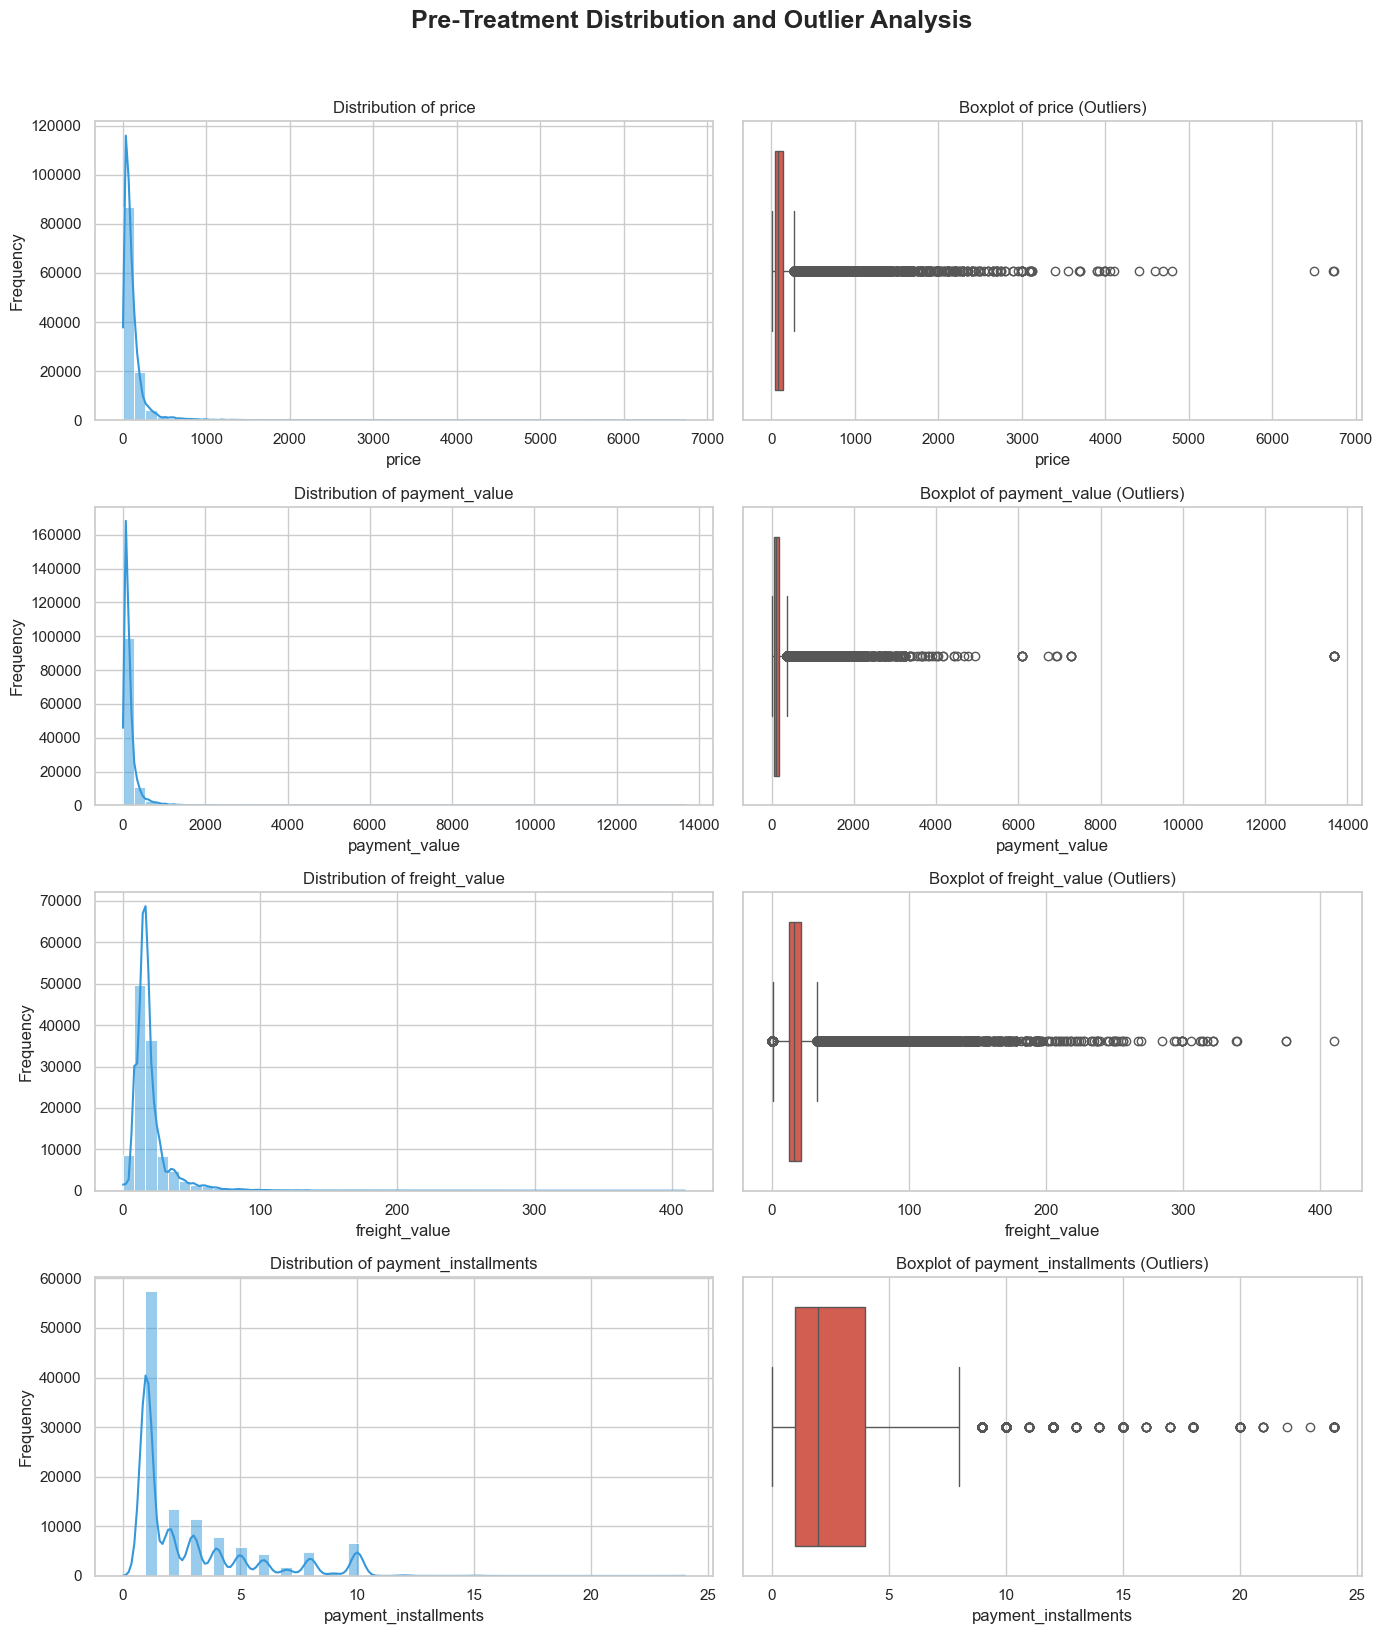

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numeric columns to visualize
numeric_cols = ['price', 'payment_value', 'freight_value', 'payment_installments']

# Set the visual style for a clean, academic look
sns.set_theme(style="whitegrid")

# Create a figure with 4 rows (one for each feature) and 2 columns (Histogram + Boxplot)
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 16))
fig.suptitle('Pre-Treatment Distribution and Outlier Analysis', fontsize=18, fontweight='bold', y=1.02)

for i, col in enumerate(numeric_cols):
    # Plot 1: Histogram (Distribution)
    sns.histplot(df[col], bins=50, kde=True, color='#3498db', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Boxplot (Outlier Detection)
    sns.boxplot(x=df[col], color='#e74c3c', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col} (Outliers)', fontsize=12)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

### Outlier Strategy: Rejecting IQR in Favor of Percentile Capping

The visual diagnostic above reveals a severe right-skewed "long tail" across all continuous financial metrics. The Interquartile Range (IQR) for these features is highly compressed near zero. 

If we were to apply a standard $3 \times \text{IQR}$ threshold, the cutoff point would be exceedingly low. In an e-commerce context, this would result in the unjustified alteration of valid, high-value wholesale or VIP transactions, fundamentally distorting the financial reality of the company's revenue streams.

Instead, we will implement an upper-bound cap at the **99th percentile**. This strategy preserves the economic weight of our top-tier buyers while mitigating the algorithmic disruption caused by the most extreme, single-instance anomalies at the very edge of the tail.


In [12]:
# 1. Define the numeric columns that need outlier treatment
numeric_cols = ['price', 'payment_value', 'freight_value', 'payment_installments']

print("--- Applying 99th Percentile Cap ---")

# 2. Loop through and clip the extreme high values directly on 'df'
for col in numeric_cols:
    upper_limit = df[col].quantile(0.99)
    print(f"{col}: Cap set at {upper_limit:.2f}")
    df[col] = df[col].clip(upper=upper_limit)

# 3. Verify the new maximums
print("\n--- Outlier Management Complete ---")
display(df[numeric_cols].describe().loc[['max']])

--- Applying 99th Percentile Cap ---
price: Cap set at 890.00
payment_value: Cap set at 1202.64
freight_value: Cap set at 84.58
payment_installments: Cap set at 10.00

--- Outlier Management Complete ---


,price,payment_value,freight_value,payment_installments
max,890.0,1202.64,84.5766,10.0


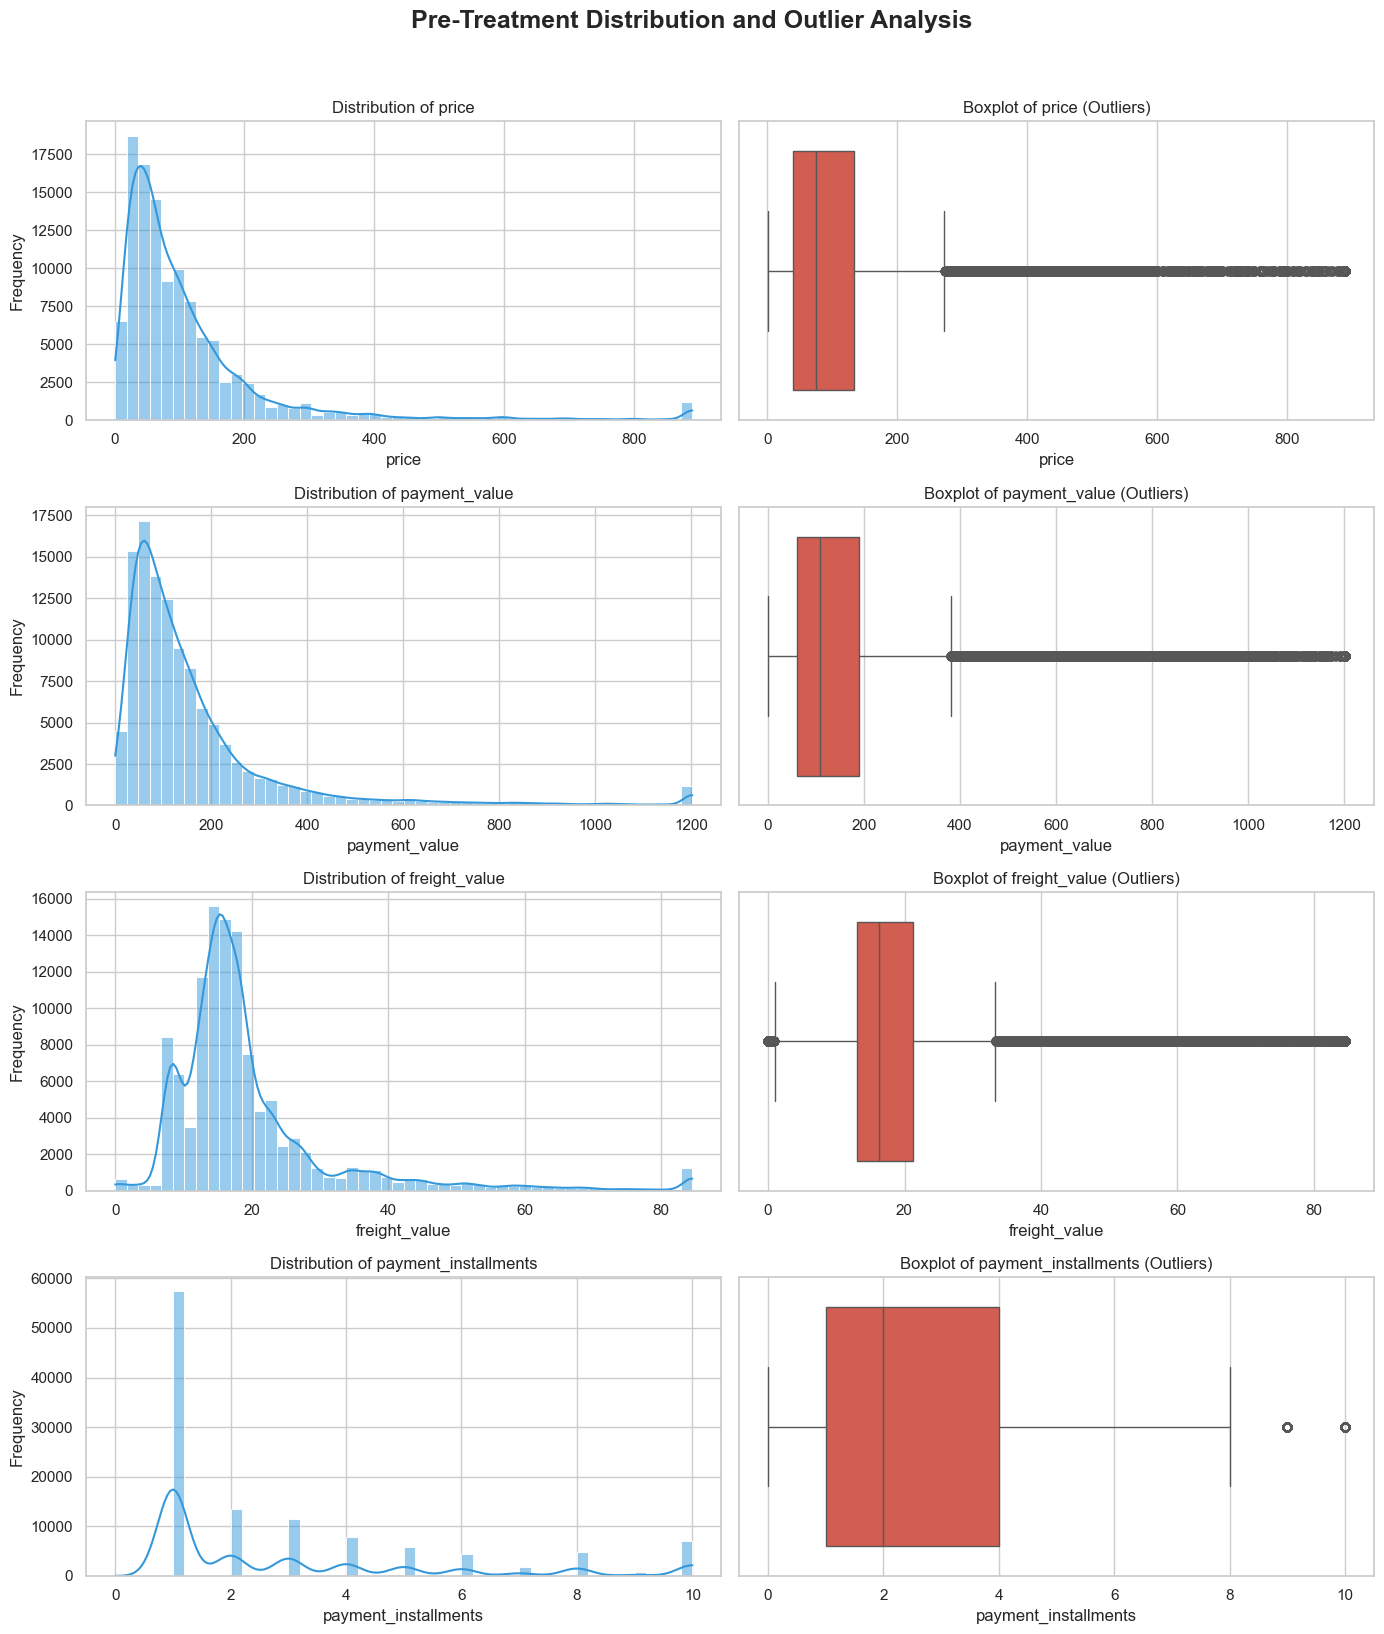

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numeric columns to visualize
numeric_cols = ['price', 'payment_value', 'freight_value', 'payment_installments']

# Set the visual style for a clean, academic look
sns.set_theme(style="whitegrid")

# Create a figure with 4 rows (one for each feature) and 2 columns (Histogram + Boxplot)
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 16))
fig.suptitle('Pre-Treatment Distribution and Outlier Analysis', fontsize=18, fontweight='bold', y=1.02)

for i, col in enumerate(numeric_cols):
    # Plot 1: Histogram (Distribution)
    sns.histplot(df[col], bins=50, kde=True, color='#3498db', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Boxplot (Outlier Detection)
    sns.boxplot(x=df[col], color='#e74c3c', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col} (Outliers)', fontsize=12)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()